In [1]:
# ── INSTALL ──────────────────────────────────────────────────────────────
!pip install xgboost scikit-learn matplotlib seaborn pandas numpy --quiet

In [2]:
# ── IMPORTS ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, matthews_corrcoef, cohen_kappa_score,
    average_precision_score, precision_recall_curve
)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
print('Imports OK')

Imports OK


In [3]:
# ── LOAD SAML-D ──────────────────────────────────────────────────────────
DATA_PATH    = 'SAML-D.csv'
TARGET_COL   = 'Label'
N_SPLITS     = 5
RANDOM_STATE = 42

df = pd.read_csv(
    DATA_PATH,
    on_bad_lines='skip',   # skips malformed rows like line 39993
    engine='python',       # more tolerant parser
    encoding='utf-8',      # try 'latin-1' if this fails
)

print(f'Shape: {df.shape}')
print(f'\nColumn list:\n{df.columns.tolist()}')
print(f'\nDtype summary:\n{df.dtypes.value_counts()}')
print(f'\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum()>0]}')

Shape: (80188, 12)

Column list:
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']

Dtype summary:
object     8
int64      2
float64    2
Name: count, dtype: int64

Missing values per column:
Received_currency         1
Sender_bank_location      1
Receiver_bank_location    1
Payment_type              1
Is_laundering             1
Laundering_type           1
dtype: int64


In [4]:
# ── PREPROCESSING ─────────────────────────────────────────────────────────

# 0. Auto-detect target column (handles case/whitespace variations)
print("Actual columns:", df.columns.tolist())

# Strip whitespace from all column names first
df.columns = df.columns.str.strip()

# Try to find the label column automatically
possible_targets = [c for c in df.columns if c.lower() in ['label','labels','class','target','attack','category']]
if possible_targets:
    TARGET_COL = possible_targets[0]
    print(f"Auto-detected target column: '{TARGET_COL}'")
else:
    # Manually set it after seeing the printed column list above
    TARGET_COL = df.columns[-1]   # fallback: last column
    print(f"Could not auto-detect — using last column: '{TARGET_COL}'")

# 1. Drop rows where target is NaN
before = len(df)
df = df.dropna(subset=[TARGET_COL])
print(f'Dropped {before - len(df)} rows with NaN target. Remaining: {len(df)}')

# 2. Encode target
le_target = LabelEncoder()
df[TARGET_COL] = le_target.fit_transform(df[TARGET_COL].astype(str))
print(f'\nClass mapping: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')
print(f'Class distribution:\n{df[TARGET_COL].value_counts()}')

# 3. Encode categorical features
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]
print(f'\nCategorical columns to encode: {cat_cols}')
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 4. Fill remaining NaNs in features with median
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]
nan_before = X.isnull().sum().sum()
X = X.fillna(X.median(numeric_only=True))
print(f'\nFilled {nan_before} NaN feature values with column median')
print(f'\nFinal X shape: {X.shape},  y unique classes: {y.nunique()}')

Actual columns: ['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']
Could not auto-detect — using last column: 'Laundering_type'
Dropped 1 rows with NaN target. Remaining: 80187

Class mapping: {'Behavioural_Change_1': np.int64(0), 'Behavioural_Change_2': np.int64(1), 'Cash_Withdrawal': np.int64(2), 'Cycle': np.int64(3), 'Deposit-Send': np.int64(4), 'Fan_In': np.int64(5), 'Layered_Fan_In': np.int64(6), 'Layered_Fan_Out': np.int64(7), 'Normal_Cash_Deposits': np.int64(8), 'Normal_Cash_Withdrawal': np.int64(9), 'Normal_Fan_In': np.int64(10), 'Normal_Fan_Out': np.int64(11), 'Normal_Foward': np.int64(12), 'Normal_Group': np.int64(13), 'Normal_Mutual': np.int64(14), 'Normal_Periodical': np.int64(15), 'Normal_Plus_Mutual': np.int64(16), 'Normal_Small_Fan_Out': np.int64(17), 'Normal_single_large': np.int64(18), 'Over-Invoicing': np.int64(19

In [5]:
# ── After all preprocessing, BEFORE the K-Fold loop ─────────────────────

# Re-encode y to guarantee contiguous 0..N-1 labels
# (dropping rows can leave gaps like missing class 24)
le_final = LabelEncoder()
y = pd.Series(le_final.fit_transform(y), index=y.index)

ALL_CLASSES = sorted(y.unique())
N_CLASSES   = len(ALL_CLASSES)
IS_BINARY   = (N_CLASSES == 2)
AVERAGE     = 'binary' if IS_BINARY else 'weighted'
CLASS_NAMES = [str(c) for c in le_final.classes_]  # original names

print(f'Classes after re-encoding: {ALL_CLASSES}')
print(f'N_CLASSES = {N_CLASSES}')
print(f'Class distribution:\n{y.value_counts().sort_index()}')

Classes after re-encoding: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
N_CLASSES = 24
Class distribution:
0         2
1         7
2        16
3         3
4         1
5         5
6         7
7         6
8       642
9      2500
10    19923
11    19306
12      360
13     4494
14      751
15     1599
16      413
17    29925
18      186
19        1
20        4
21        2
22        7
23       27
Name: count, dtype: int64


In [6]:
# ── DETECT BINARY vs MULTICLASS ──────────────────────────────────────────
N_CLASSES = y.nunique()
IS_BINARY = (N_CLASSES == 2)
AVERAGE   = 'binary' if IS_BINARY else 'weighted'
print(f'Task: {"Binary" if IS_BINARY else "Multiclass"} ({N_CLASSES} classes)')

Task: Multiclass (24 classes)


In [7]:
# ── XGBoost MODEL ────────────────────────────────────────────────────────
import xgboost as xgb
print(f'XGBoost version: {xgb.__version__}')

xgb_params = dict(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss' if IS_BINARY else 'mlogloss',
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    objective        = 'binary:logistic' if IS_BINARY else 'multi:softprob',
    tree_method      = 'hist',   # faster, works on CPU & GPU
)

if not IS_BINARY:
    xgb_params['num_class'] = N_CLASSES   # must match re-encoded y

print('XGBoost config:')
for k, v in xgb_params.items():
    print(f'  {k:20s}: {v}')

XGBoost version: 3.2.0
XGBoost config:
  n_estimators        : 300
  max_depth           : 6
  learning_rate       : 0.05
  subsample           : 0.8
  colsample_bytree    : 0.8
  eval_metric         : mlogloss
  random_state        : 42
  n_jobs              : -1
  objective           : multi:softprob
  tree_method         : hist
  num_class           : 24


In [9]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_raw, y_test_raw = y.iloc[train_idx], y.iloc[test_idx]

    # ── Re-encode per fold to guarantee 0..N-1 with no gaps ──────────────
    fold_le = LabelEncoder()
    fold_le.fit(y_train_raw)                          # fit only on train classes
    y_train = pd.Series(fold_le.transform(y_train_raw), index=y_train_raw.index)

    # For test: unseen classes → map to nearest or drop those rows
    test_mask = y_test_raw.isin(fold_le.classes_)
    if not test_mask.all():
        n_dropped = (~test_mask).sum()
        print(f'  [Fold {fold}] Dropping {n_dropped} test rows with unseen classes')
    X_test_f  = X_test[test_mask]
    y_test_enc = pd.Series(
        fold_le.transform(y_test_raw[test_mask]),
        index=y_test_raw[test_mask].index
    )

    fold_n_classes = len(fold_le.classes_)
    fold_class_names = [CLASS_NAMES[c] for c in fold_le.classes_]

    # Update num_class for this fold
    fold_params = xgb_params.copy()
    fold_params['num_class'] = fold_n_classes

    model = XGBClassifier(**fold_params)
    model.fit(X_train, y_train, eval_set=[(X_test_f, y_test_enc)], verbose=False)

    y_pred_enc = model.predict(X_test_f)
    y_proba    = model.predict_proba(X_test_f)   # shape: (n, fold_n_classes)

    # Map predictions back to global class space
    y_pred_global = np.array([fold_le.classes_[p] for p in y_pred_enc])
    y_test_global = y_test_raw[test_mask].values

    # Aligned proba in global class space
    proba_aligned = np.zeros((len(X_test_f), N_CLASSES))
    for j, cls in enumerate(fold_le.classes_):
        proba_aligned[:, cls] = y_proba[:, j]

    # OOF storage (use original indices)
    valid_test_idx = test_idx[test_mask.values]
    oof_pred[valid_test_idx]     = y_pred_global
    oof_proba[valid_test_idx]    = proba_aligned

    # ── Metrics (use global labels) ───────────────────────────────────────
    acc  = accuracy_score(y_test_global, y_pred_global)
    prec = precision_score(y_test_global, y_pred_global, average=AVERAGE, zero_division=0)
    rec  = recall_score(y_test_global, y_pred_global, average=AVERAGE, zero_division=0)
    f1   = f1_score(y_test_global, y_pred_global, average=AVERAGE, zero_division=0)
    mcc  = matthews_corrcoef(y_test_global, y_pred_global)
    kap  = cohen_kappa_score(y_test_global, y_pred_global)

    classes_in_fold = sorted(np.unique(y_test_global))
    fold_proba_sub  = proba_aligned[:, classes_in_fold]
    row_sums = fold_proba_sub.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    fold_proba_sub  = fold_proba_sub / row_sums

    try:
        auc = roc_auc_score(y_test_global, fold_proba_sub,
                            multi_class='ovr', average='weighted',
                            labels=classes_in_fold)
        ap  = average_precision_score(
                  pd.get_dummies(pd.Series(y_test_global)).values,
                  fold_proba_sub, average='weighted')
    except ValueError as e:
        print(f'  [Fold {fold}] AUC skipped: {e}')
        auc, ap = float('nan'), float('nan')

    cm = confusion_matrix(y_test_global, y_pred_global, labels=ALL_CLASSES)
    feature_imp += model.feature_importances_

    # ── Print ─────────────────────────────────────────────────────────────
    fold_results.append({
        'Fold': fold, 'Train Size': len(train_idx), 'Test Size': len(valid_test_idx),
        'Accuracy': round(acc,4), 'Precision': round(prec,4), 'Recall': round(rec,4),
        'F1-Score': round(f1,4), 'AUC-ROC': round(auc,4), 'Avg Precision': round(ap,4),
        'MCC': round(mcc,4), 'Kappa': round(kap,4),
    })
    fold_cms.append(cm)
    fold_auc.append(auc); fold_ap.append(ap)

    print(f'FOLD {fold}/{N_SPLITS}')
    print(f'  Train: {len(train_idx):,}  |  Test: {len(valid_test_idx):,}  |  Fold classes: {fold_n_classes}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}   Recall : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}   AUC-ROC: {auc:.4f}')
    print(f'  Avg Prec  : {ap:.4f}   MCC    : {mcc:.4f}   Kappa: {kap:.4f}')
    print(f'\n  Classification Report (Fold {fold}):')
    print(classification_report(y_test_global, y_pred_global,
                                labels=ALL_CLASSES, target_names=CLASS_NAMES, zero_division=0))
    print('-'*70)

feature_imp /= N_SPLITS

  [Fold 1] Dropping 1 test rows with unseen classes
FOLD 1/5
  Train: 64,149  |  Test: 16,037  |  Fold classes: 23
  Accuracy  : 0.7818
  Precision : 0.7420   Recall : 0.7818
  F1-Score  : 0.7524   AUC-ROC: 0.9405
  Avg Prec  : 0.8397   MCC    : 0.7045   Kappa: 0.6985

  Classification Report (Fold 1):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         2
           8       0.99      1.00      1.00       129
           9       1.00      0.98      0.99       500
          10       0.71      0.92      0.81      3985
          11       0.77      0.91      0.83    

In [11]:
# ── SUMMARY TABLE ────────────────────────────────────────────────────────
results_df = pd.DataFrame(fold_results)

# Add mean ± std row
metric_cols = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','Avg Precision','MCC','Kappa']
mean_row = {'Fold': 'MEAN'}
std_row  = {'Fold': 'STD'}
for col in metric_cols:
    mean_row[col] = round(results_df[col].mean(), 4)
    std_row[col]  = round(results_df[col].std(),  4)
summary_df = pd.concat([results_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)

print('\n' + '='*70)
print('CROSS-VALIDATION SUMMARY')
print('='*70)
print(summary_df.to_string(index=False))
print('='*70)


CROSS-VALIDATION SUMMARY
Fold  Train Size  Test Size  Accuracy  Precision  Recall  F1-Score  AUC-ROC  Avg Precision    MCC  Kappa
   1     64149.0    16037.0    0.7818     0.7420  0.7818    0.7524   0.9405         0.8397 0.7045 0.6985
   2     64149.0    16037.0    0.7886     0.7468  0.7886    0.7586   0.9424         0.8413 0.7131 0.7075
   3     64150.0    16037.0    0.7904     0.7479  0.7904    0.7603   0.9427         0.8424 0.7162 0.7103
   4     64150.0    16037.0    0.7886     0.7474  0.7886    0.7590   0.9409         0.8405 0.7132 0.7077
   5     64150.0    16037.0    0.7888     0.7475  0.7888    0.7589   0.9418         0.8425 0.7141 0.7081
MEAN         NaN        NaN    0.7876     0.7463  0.7876    0.7578   0.9417         0.8413 0.7122 0.7064
 STD         NaN        NaN    0.0034     0.0024  0.0034    0.0031   0.0009         0.0012 0.0045 0.0046


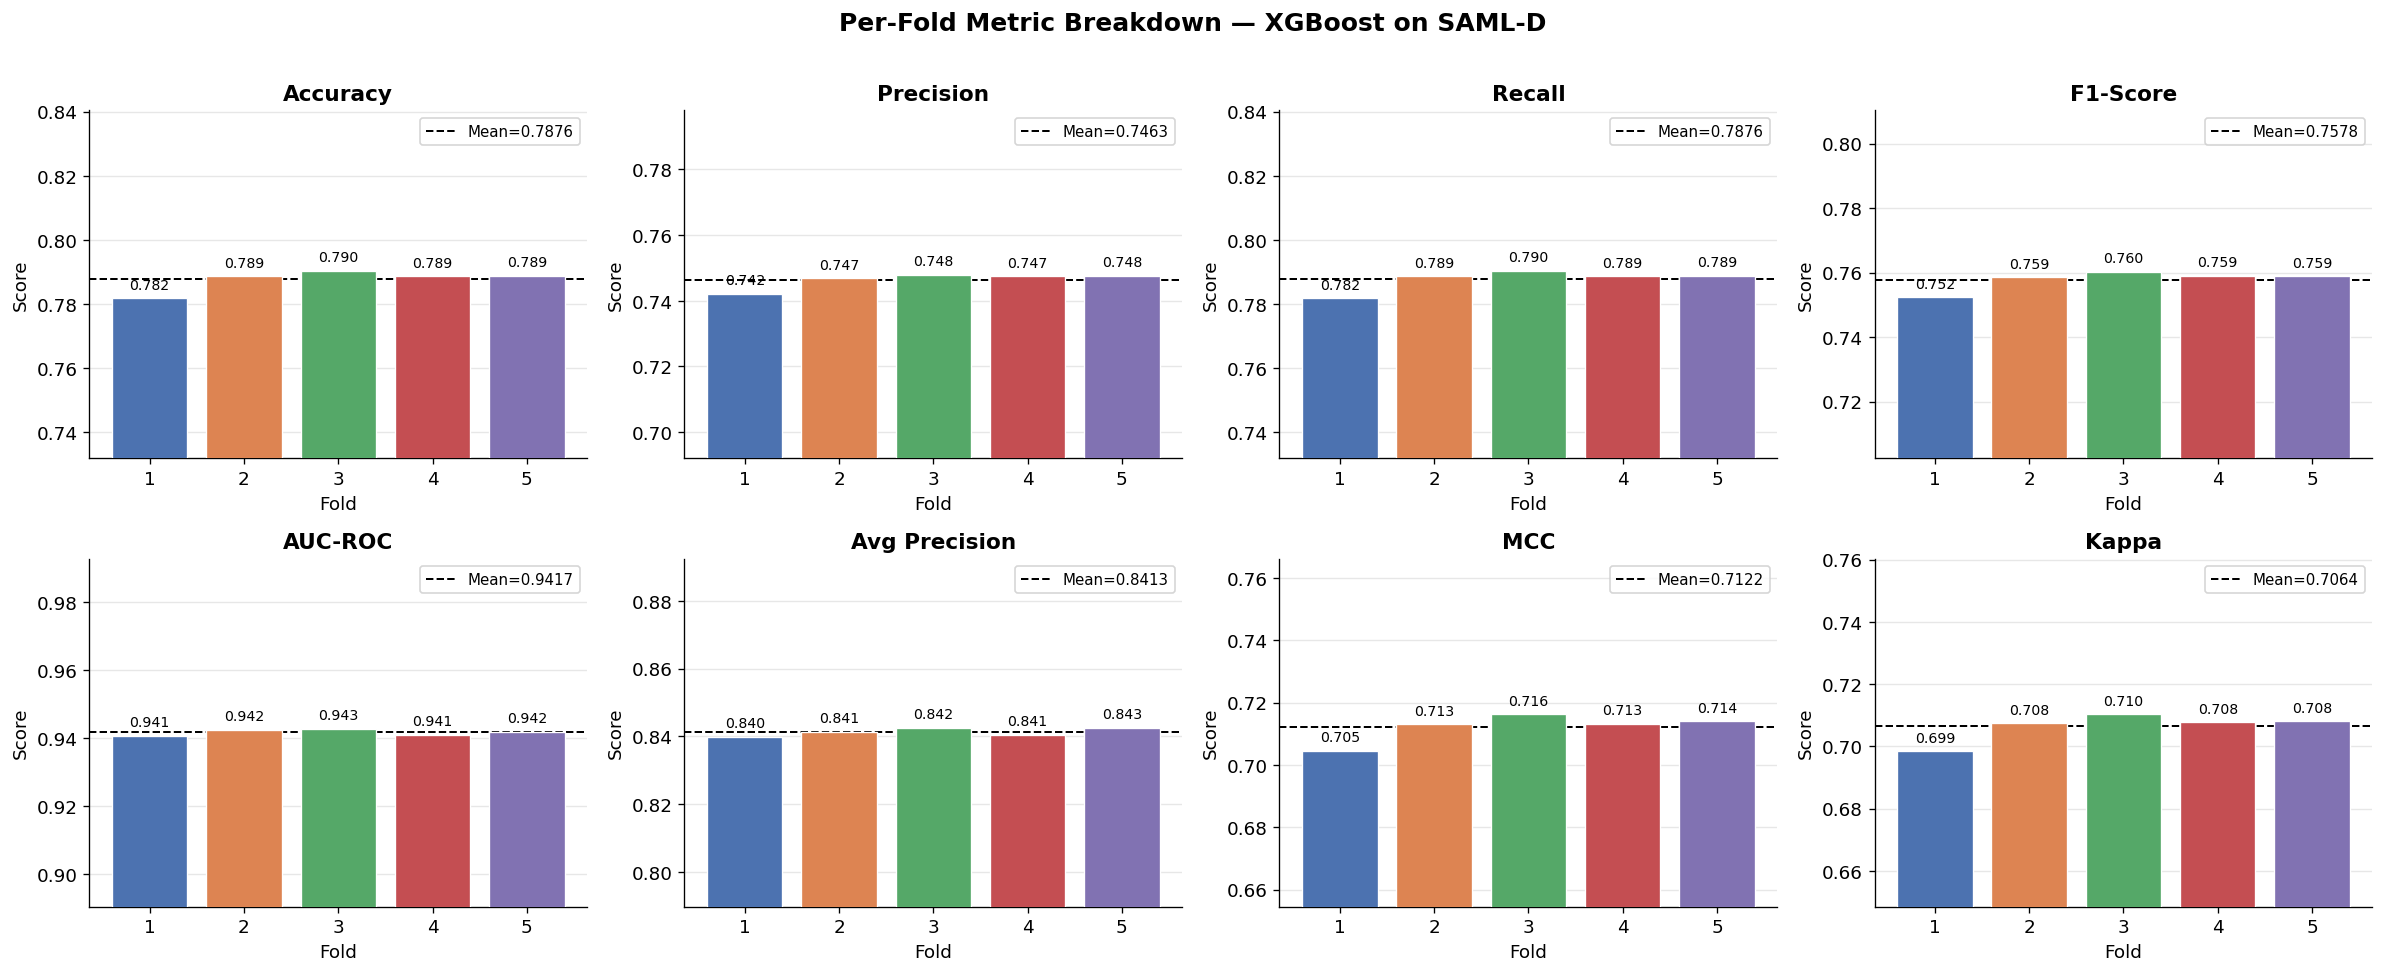

Saved: fold_metrics_bar.png


In [12]:
# ── VIZ 1: Per-Fold Metrics Bar Chart ────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Per-Fold Metric Breakdown — XGBoost on SAML-D', fontsize=15, fontweight='bold', y=1.01)

metrics_to_plot = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','Avg Precision','MCC','Kappa']
folds = results_df['Fold'].tolist()

for ax, metric in zip(axes.flat, metrics_to_plot):
    vals = results_df[metric].tolist()
    bars = ax.bar(folds, vals, color=PALETTE, edgecolor='white', linewidth=0.8, zorder=3)
    mean_val = np.mean(vals)
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:.4f}')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_xticks(folds)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    # Value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)
    ymin = max(0, min(vals) - 0.05)
    ymax = min(1, max(vals) + 0.05)
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig('fold_metrics_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fold_metrics_bar.png')

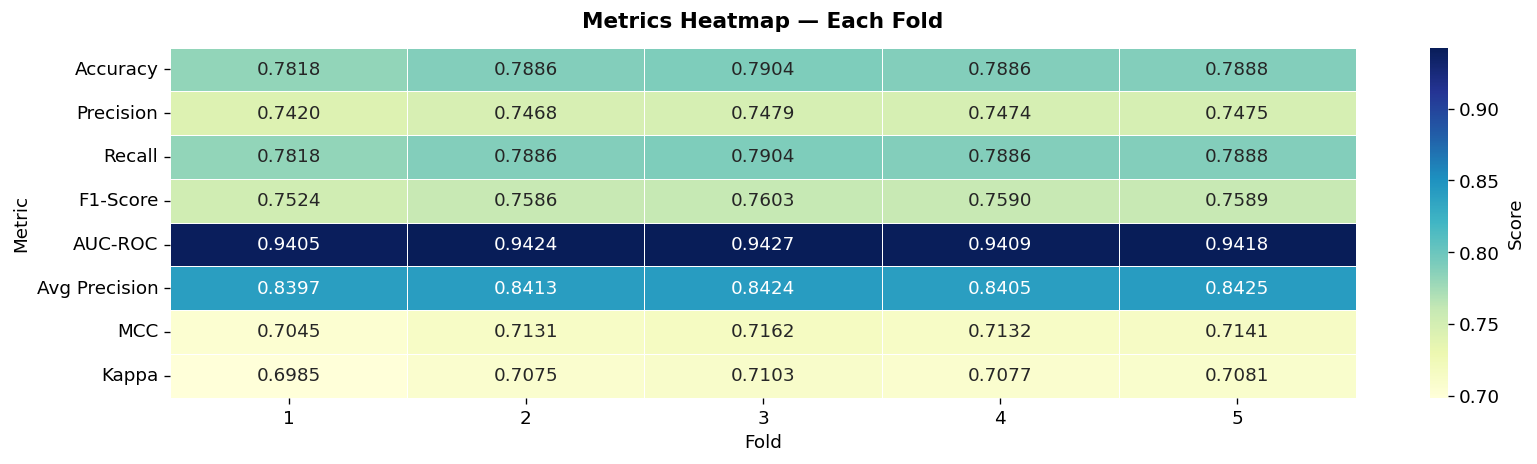

Saved: fold_metrics_heatmap.png


In [13]:
# ── VIZ 2: Metrics Heatmap ────────────────────────────────────────────────
heat_data = results_df[['Fold'] + metric_cols].set_index('Fold')[metric_cols].astype(float)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heat_data.T, annot=True, fmt='.4f',
    cmap='YlGnBu', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Score'}
)
ax.set_title('Metrics Heatmap — Each Fold', fontweight='bold', pad=12)
ax.set_xlabel('Fold')
ax.set_ylabel('Metric')
plt.tight_layout()
plt.savefig('fold_metrics_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fold_metrics_heatmap.png')

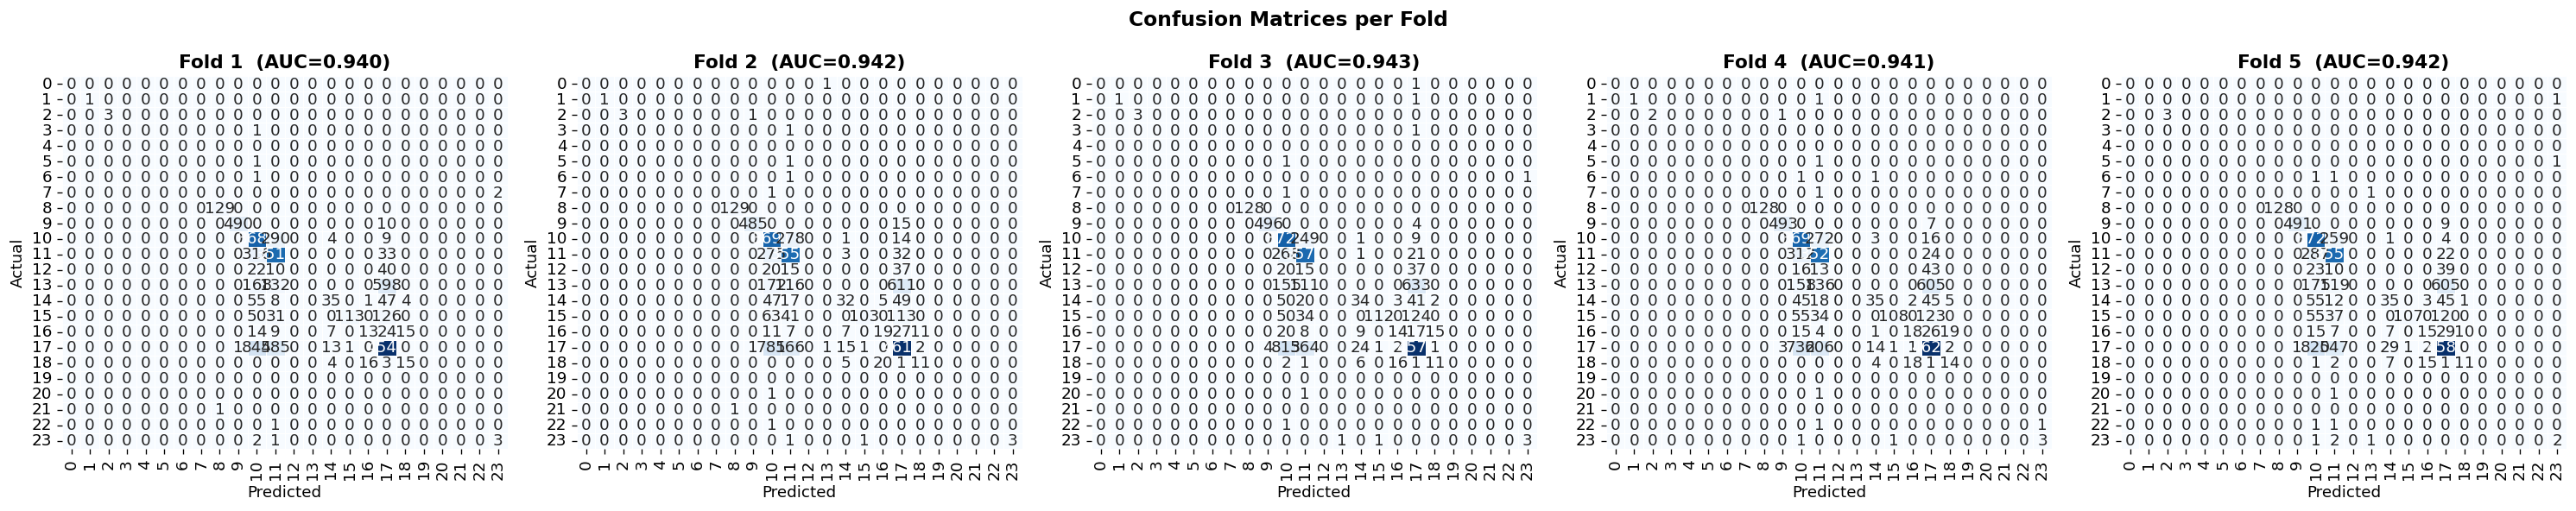

Saved: fold_confusion_matrices.png


In [14]:
# ── VIZ 3: Confusion Matrices (one per fold) ──────────────────────────────
ncols = N_SPLITS
fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5))
fig.suptitle('Confusion Matrices per Fold', fontsize=14, fontweight='bold')

for i, (ax, cm) in enumerate(zip(axes, fold_cms), 1):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5, cbar=False
    )
    ax.set_title(f'Fold {i}  (AUC={fold_auc[i-1]:.3f})', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('fold_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fold_confusion_matrices.png')

In [15]:
# ── VIZ 4: ROC Curves (binary only) ──────────────────────────────────────
if IS_BINARY:
    fig, ax = plt.subplots(figsize=(8, 7))

    for i in range(N_SPLITS):
        ax.plot(fold_fpr[i], fold_tpr[i],
                color=PALETTE[i % len(PALETTE)], lw=1.5, alpha=0.85,
                label=f'Fold {i+1}  AUC = {fold_auc[i]:.4f}')

    # Mean ROC
    mean_fpr = np.linspace(0, 1, 200)
    interp_tprs = [np.interp(mean_fpr, fold_fpr[i], fold_tpr[i]) for i in range(N_SPLITS)]
    mean_tpr = np.mean(interp_tprs, axis=0)
    mean_auc = np.mean(fold_auc)
    std_auc  = np.std(fold_auc)
    ax.plot(mean_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
            label=f'Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}')

    # Std band
    std_tpr = np.std(interp_tprs, axis=0)
    ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, alpha=0.15, color='grey')

    ax.plot([0,1],[0,1],'k:',lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves — All Folds + Mean ± Std', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: roc_curves.png')
else:
    print(f'Multiclass: Mean weighted AUC-ROC = {np.mean(fold_auc):.4f} ± {np.std(fold_auc):.4f}')

Multiclass: Mean weighted AUC-ROC = 0.9417 ± 0.0008


In [17]:
# ── VIZ 5: Precision-Recall Curves (binary only) ──────────────────────────
if IS_BINARY:
    fig, ax = plt.subplots(figsize=(8, 7))

    for i in range(N_SPLITS):
        ax.plot(fold_pr_rec[i], fold_pr_prec[i],
                color=PALETTE[i % len(PALETTE)], lw=1.5, alpha=0.85,
                label=f'Fold {i+1}  AP = {fold_ap[i]:.4f}')

    mean_ap = np.mean(fold_ap)
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'Precision-Recall Curves (Mean AP = {mean_ap:.4f})', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('pr_curves.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: pr_curves.png')

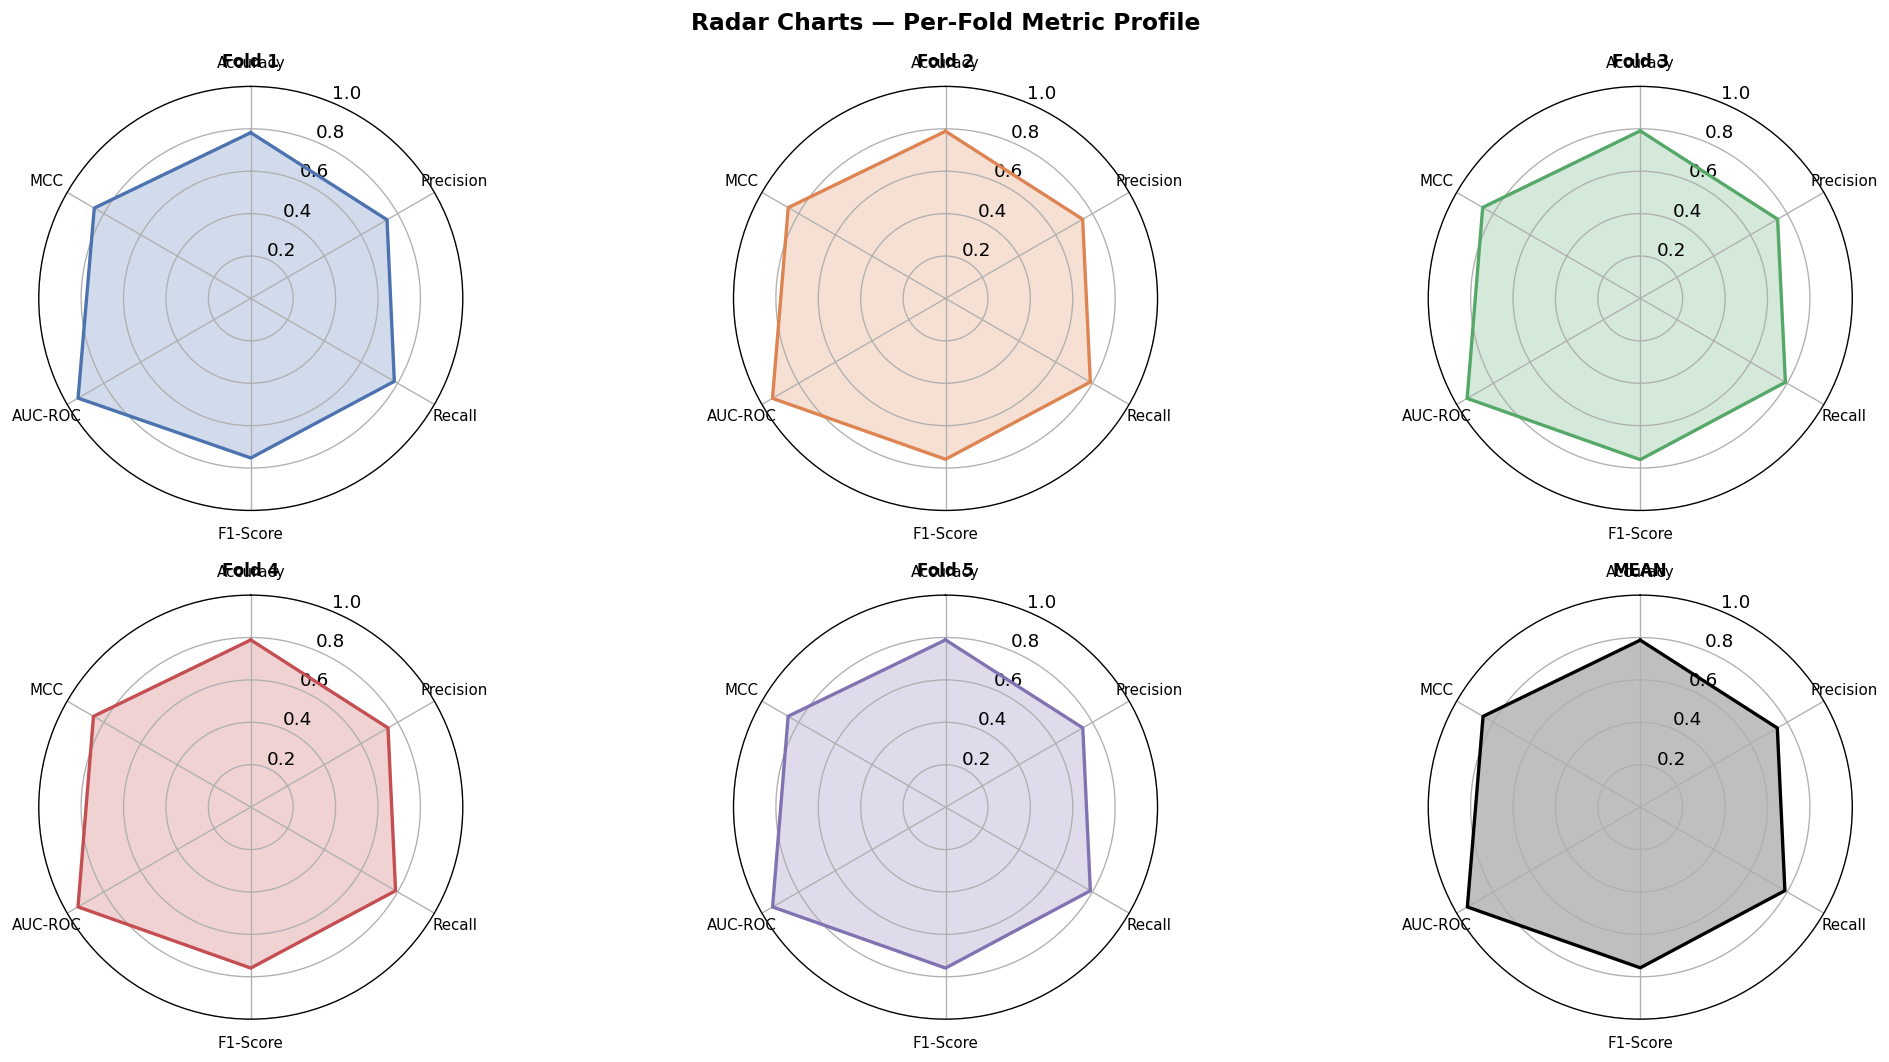

Saved: radar_charts.png


In [18]:
# ── VIZ 6: Metrics Radar / Spider Chart ───────────────────────────────────
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','MCC']

def radar_chart(ax, values, labels, color, fold_label):
    N = len(labels)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    values = list(values) + [values[0]]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_title(fold_label, size=10, fontweight='bold', pad=12)

fig = plt.figure(figsize=(18, 9))
fig.suptitle('Radar Charts — Per-Fold Metric Profile', fontsize=14, fontweight='bold')

for i in range(N_SPLITS):
    ax = fig.add_subplot(2, 3, i+1, polar=True)
    vals = [results_df.loc[i, m] for m in radar_metrics]
    # Normalize MCC from [-1,1] to [0,1]
    vals[-1] = (vals[-1] + 1) / 2
    radar_chart(ax, vals, radar_metrics, PALETTE[i % len(PALETTE)], f'Fold {i+1}')

# Mean radar
ax = fig.add_subplot(2, 3, N_SPLITS+1, polar=True)
mean_vals = [results_df[m].mean() for m in radar_metrics]
mean_vals[-1] = (mean_vals[-1] + 1) / 2
radar_chart(ax, mean_vals, radar_metrics, 'black', 'MEAN')

plt.tight_layout()
plt.savefig('radar_charts.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: radar_charts.png')

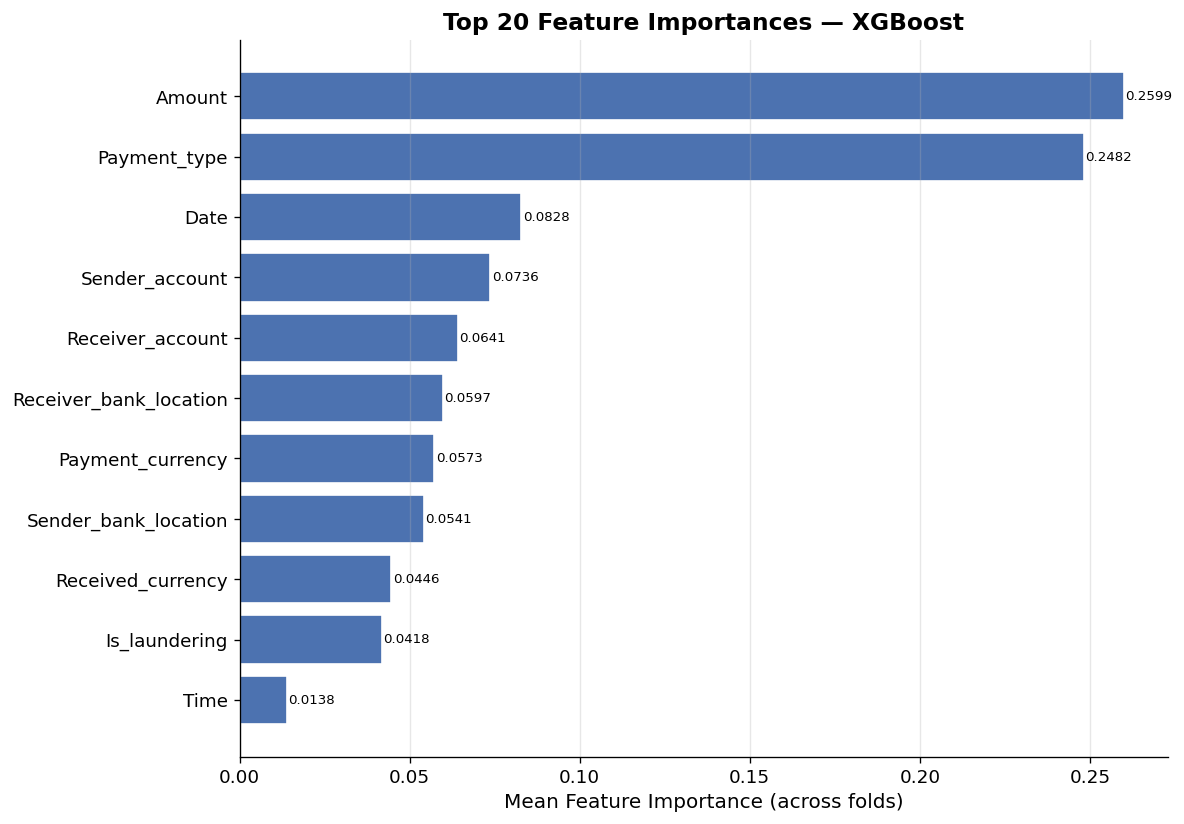

Saved: feature_importances.png


In [19]:
# ── VIZ 7: Feature Importances ───────────────────────────────────────────
TOP_N = 20
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_imp})
feat_df = feat_df.sort_values('Importance', ascending=False).head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
               color='#4C72B0', edgecolor='white')
ax.set_xlabel('Mean Feature Importance (across folds)', fontsize=12)
ax.set_title(f'Top {TOP_N} Feature Importances — XGBoost', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, feat_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: feature_importances.png')

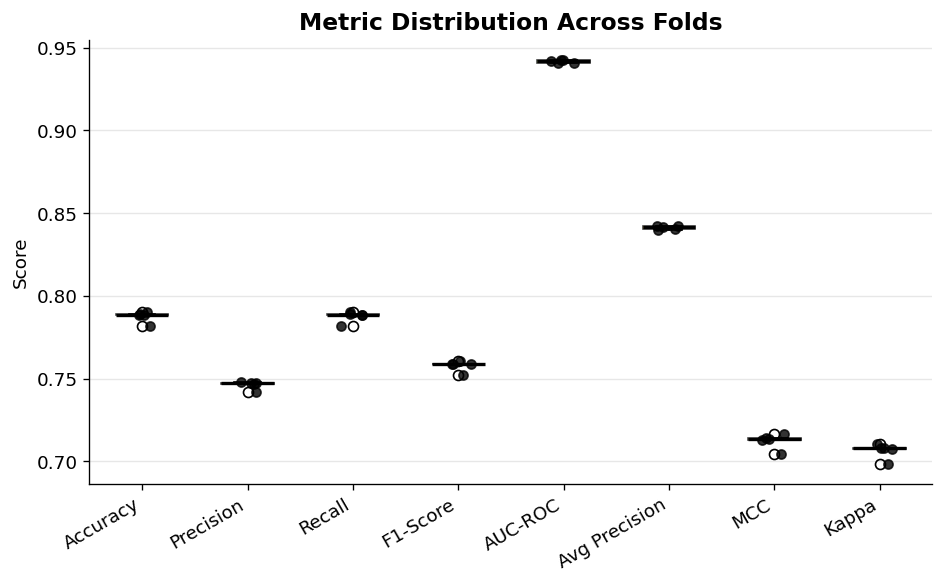

Saved: metric_boxplot.png


In [20]:
# ── VIZ 8: AUC Boxplot + Swarm ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
metric_matrix = results_df[metric_cols].values.T  # shape (n_metrics, n_folds)

bp = ax.boxplot(metric_matrix.T, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', len(metric_cols))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Overlay scatter
for i, vals in enumerate(metric_matrix, 1):
    jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, color='black', s=30, zorder=5, alpha=0.8)

ax.set_xticks(range(1, len(metric_cols)+1))
ax.set_xticklabels(metric_cols, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Metric Distribution Across Folds', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metric_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: metric_boxplot.png')


OUT-OF-FOLD (OOF) OVERALL EVALUATION
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      0.57      0.73         7
           2       1.00      0.88      0.93        16
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00         7
           7       0.00      0.00      0.00         6
           8       1.00      1.00      1.00       642
           9       1.00      0.98      0.99      2500
          10       0.73      0.93      0.81     19923
          11       0.77      0.92      0.84     19306
          12       0.00      0.00      0.00       360
          13       0.00      0.00      0.00      4494
          14       0.51      0.23      0.31       751
          15       0.99      0.34      0.51      1599
          16       0.43      0.19      0.27

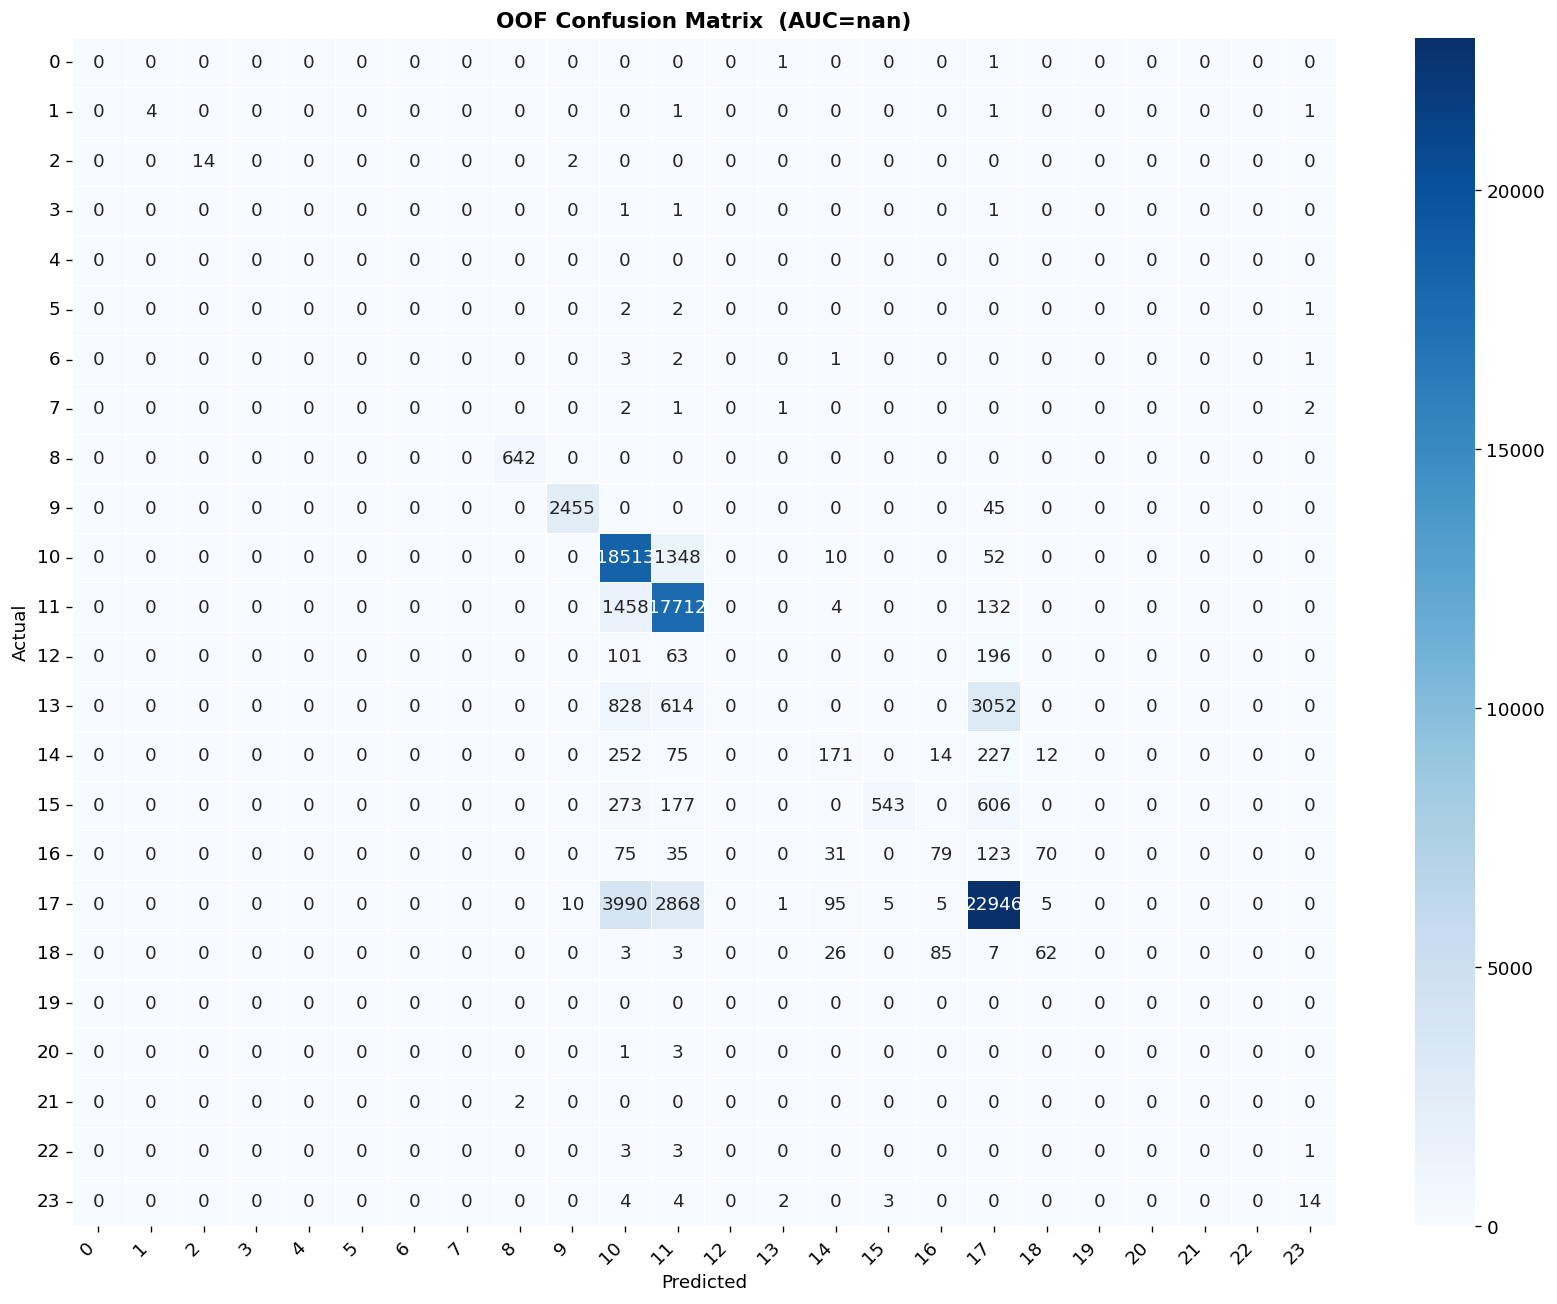

In [23]:
# ── OOF FINAL REPORT ─────────────────────────────────────────────────────
print('\n' + '='*70)
print('OUT-OF-FOLD (OOF) OVERALL EVALUATION')
print('='*70)

# Only evaluate rows that were actually predicted (non-zero rows)
if IS_BINARY:
    predicted_mask = oof_proba != 0
else:
    predicted_mask = oof_proba.sum(axis=1) > 0   # rows with at least some proba filled

y_eval        = y[predicted_mask]
oof_pred_eval = oof_pred[predicted_mask]

print(classification_report(y_eval, oof_pred_eval,
                             labels=ALL_CLASSES, target_names=CLASS_NAMES, zero_division=0))

oof_acc = accuracy_score(y_eval, oof_pred_eval)
oof_f1  = f1_score(y_eval, oof_pred_eval, average=AVERAGE, zero_division=0)
oof_mcc = matthews_corrcoef(y_eval, oof_pred_eval)

# Normalize proba rows to sum to 1 before AUC
if IS_BINARY:
    oof_proba_eval = oof_proba[predicted_mask]
    oof_auc = roc_auc_score(y_eval, oof_proba_eval)
else:
    oof_proba_eval = oof_proba[predicted_mask]
    row_sums = oof_proba_eval.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1                          # avoid div by zero
    oof_proba_norm = oof_proba_eval / row_sums           # now every row sums to 1

    # Only include classes that actually appear in y_eval
    classes_present = sorted(y_eval.unique())
    try:
        oof_auc = roc_auc_score(
            y_eval,
            oof_proba_norm[:, classes_present],
            multi_class='ovr',
            average='weighted',
            labels=classes_present
        )
    except ValueError as e:
        print(f'OOF AUC skipped: {e}')
        oof_auc = float('nan')

print(f'OOF Accuracy : {oof_acc:.4f}')
print(f'OOF F1-Score : {oof_f1:.4f}')
print(f'OOF AUC-ROC  : {oof_auc:.4f}')
print(f'OOF MCC      : {oof_mcc:.4f}')
print(f'Rows evaluated: {predicted_mask.sum():,} / {len(y):,}')

# OOF Confusion Matrix
fig, ax = plt.subplots(figsize=(14, 11))
oof_cm = confusion_matrix(y_eval, oof_pred_eval, labels=ALL_CLASSES)
sns.heatmap(oof_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.3)
ax.set_title(f'OOF Confusion Matrix  (AUC={oof_auc:.4f})', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('oof_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()